# Implementation of the model by Gu et al.

Steady-state redox model of photosynthetic linear electron transport.

## Model summary

The model provides a simplified steady-state description of linear photosynthetic electron transport. It represents electron flow through PSII, the plastoquinone pool, and cytochrome b$_6f$ using composite redox parameters rather than explicit elementary reaction steps.

The model is intended to link chlorophyll fluorescence-derived variables with estimates of photosynthetic electron transport rate, while remaining sufficiently compact for integration into broader photosynthesis or crop-scale modelling frameworks.

### Source:
https://doi.org/10.1111/pce.14563

In [97]:
import matplotlib.pyplot as plt
import numpy as np

from mxlmodels import get_gu2023
import pandas as pd

In [98]:
# ============================================================
# Parameters from uploaded supplementary table
# Used for the organism-specific OC-model reconstruction
# ============================================================

species_params = {
    "Solanum lycopersicum": {
        "U": 1714.1947,
        "R1": 0.3111,
        "R2": 0.0000,
        "q_r": 0.8598,
        "a_q": -0.8017,
        "b_s": 0.0042,
        "c_s": 15.5232,
    },
    "Betula alleghaniensis": {
        "U": 1189.0250,
        "R1": 0.4702,
        "R2": 0.0000,
        "q_r": 0.8636,
        "a_q": -0.6134,
        "b_s": 0.0014,
        "c_s": 6.8590,
    },
    "Liquidambar styraciflua": {
        "U": 846.8143,
        "R1": 0.5016,
        "R2": 0.0000,
        "q_r": 0.8906,
        "a_q": -0.5597,
        "b_s": 0.0020,
        "c_s": 4.6041,
    },
    "Oryza sativa": {
        "U": 963.4558,
        "R1": 0.5733,
        "R2": 0.0000,
        "q_r": 0.7623,
        "a_q": -0.5597,
        "b_s": 0.0024,
        "c_s": 7.2908,
    },
    "Carya ovata": {
        "U": 981.3335,
        "R1": 0.5668,
        "R2": 0.0000,
        "q_r": 0.7805,
        "a_q": -0.5548,
        "b_s": 0.0015,
        "c_s": 4.8562,
    },
    "Andropogon gerardii": {
        "U": 571.5778,
        "R1": 0.4538,
        "R2": 0.0000,
        "q_r": 0.9564,
        "a_q": -0.5711,
        "b_s": 0.0021,
        "c_s": 4.5994,
    },
    "Gossypium hirsutum": {
        "U": 1486.8670,
        "R1": 0.3988,
        "R2": 0.0011,
        "q_r": 0.9480,
        "a_q": -0.6342,
        "b_s": 0.0016,
        "c_s": 5.5211,
    },
    "Juglans nigra": {
        "U": 1312.6150,
        "R1": 0.4113,
        "R2": 0.0000,
        "q_r": 0.8110,
        "a_q": -0.7258,
        "b_s": 0.0021,
        "c_s": 5.5501,
    },
    "Zea mays": {
        "U": 726.9816,
        "R1": 0.3761,
        "R2": 0.0000,
        "q_r": 0.9196,
        "a_q": -0.6785,
        "b_s": 0.0021,
        "c_s": 5.5157,
    },
}

## Reproduce Figure 3
### Redox stoichiometry relationship between Cyt and PSII.

h_cyt = fraction of cytochrome b6f complex available for LET

q     = fraction of open PSII reaction centres

a_q   = Cyt–PSII stoichiometry parameter

## Figure 3

In [103]:

fig3_res = pd.DataFrame({
    "q": np.linspace(1e-5, 1, 100)
})

for val in [10, 2, 0, -0.5, -0.9]:
    fig3_res[f"aq_{val}"] = fig3_res["q"].apply(lambda q: get_gu2023(q=q, a_q=val)["h_cyt"])
    
fig3_res = fig3_res.set_index("q")

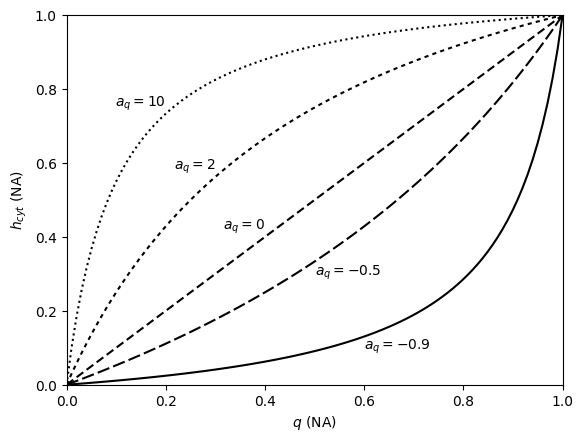

In [100]:
fig3, ax = plt.subplots()

plot_stylings = {
    "aq_10": {"ls": ":"},
    "aq_2": {"dashes": (2, 2)},
    "aq_0": {"dashes": (4, 2)},
    "aq_-0.5": {"dashes": (6, 2)},
    "aq_-0.9": {"ls": "-"}
}

text_xval = 0.2
for col in fig3_res.columns:
    ax.plot(fig3_res[col], label=col, color="black", **plot_stylings.get(col, {}))

    num = col.split("_")[-1]
    
    text_yvals = fig3_res.iloc[fig3_res.index.get_indexer([text_xval], method="nearest")[0]]
    va = "bottom" if float(num) >= 0 else "top"
    ha = "right" if float(num) >= 0 else "left"
    ax.text(
        x=text_xval,
        y=text_yvals[col],
        s=f"$a_q = {num}$",
        va=va,
        ha=ha
    )
    text_xval += 0.1

ax.set_xlabel("$q$ (NA)")
ax.set_xlim(0.0, 1.0)

ax.set_ylabel("$h_{cyt}$ (NA)")
ax.set_ylim(0.0, 1.0)

plt.show()

## Figure 8

As figure uses data that us not given, only a schematic recreation can be presented

In [101]:
shape_params = {
    "Solanum lycopersicum": {"q_min": 0.12, "q_max": 0.98, "k": 430},
    "Betula alleghaniensis": {"q_min": 0.22, "q_max": 0.98, "k": 520},
    "Liquidambar styraciflua": {"q_min": 0.25, "q_max": 0.98, "k": 620},
    "Oryza sativa": {"q_min": 0.10, "q_max": 0.95, "k": 330},
    "Carya ovata": {"q_min": 0.22, "q_max": 0.98, "k": 540},
    "Andropogon gerardii": {"q_min": 0.18, "q_max": 0.95, "k": 650},
    "Gossypium hirsutum": {"q_min": 0.32, "q_max": 0.98, "k": 750},
    "Juglans nigra": {"q_min": 0.20, "q_max": 0.98, "k": 500},
    "Zea mays": {"q_min": 0.28, "q_max": 0.98, "k": 600},
}

def q_l_from_par(PAR, q_min, q_max, k):
    """
    Empirical light-response decline of q_L with PAR.
    Used only to visually reconstruct the published figure.
    """
    return q_min + (q_max - q_min) * np.exp(-PAR / k)

fig8_res = {}
PAR_series = np.linspace(0, 2000, 20)

for species, params in species_params.items():
    fig8_res[species] = pd.DataFrame({
        "PAR": PAR_series
    })
    fig8_res[species]["q"] = fig8_res[species]["PAR"].apply(lambda PAR: q_l_from_par(PAR, **shape_params[species]))
    fig8_res[species]["h_cyt"] = fig8_res[species].apply(lambda row: get_gu2023(q=row["q"], PAR=row["PAR"], **params)["h_cyt"], axis=1)
    fig8_res[species]["h_pq"] = fig8_res[species].apply(lambda row: get_gu2023(q=row["q"], PAR=row["PAR"], **params)["h_pq"], axis=1)
    fig8_res[species] = fig8_res[species].set_index("PAR")

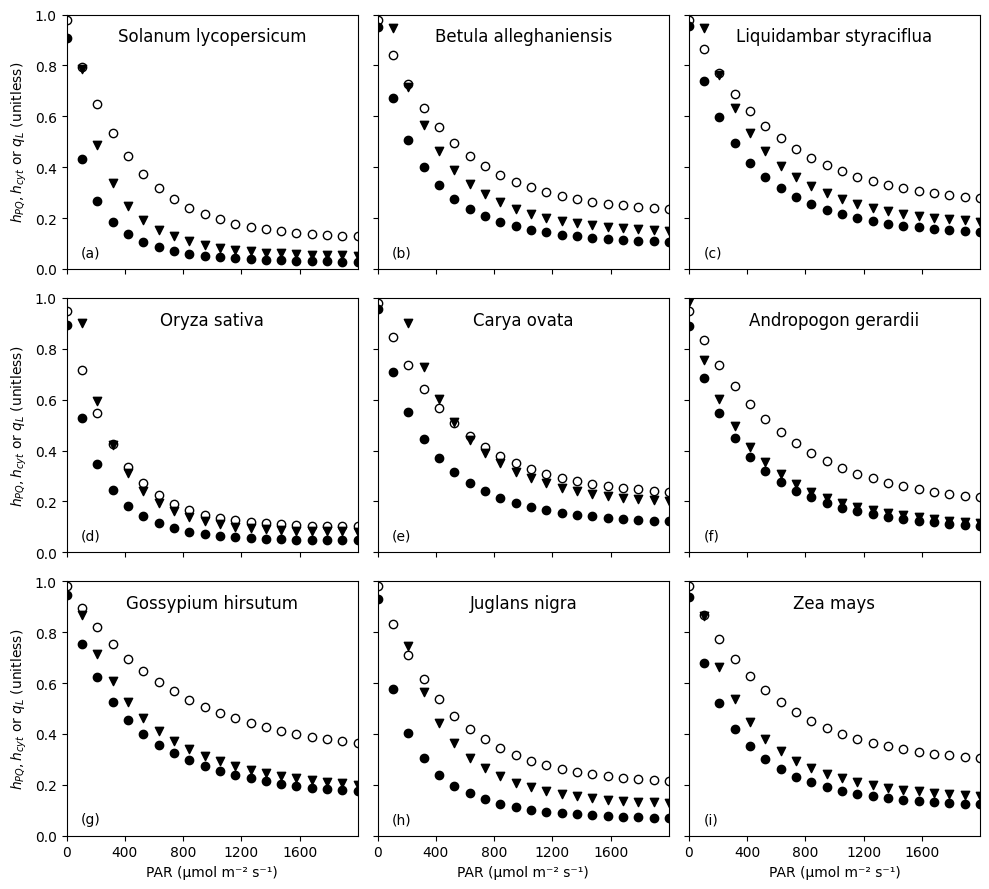

In [102]:
fig5, axs = plt.subplot_mosaic([["a", "b", "c"], ["d", "e", "f"], ["g", "h", "i"]], figsize=(10, 9), sharex=True, sharey=True)

species_plot = {
    "a": "Solanum lycopersicum",
    "b":  "Betula alleghaniensis",
    "c": "Liquidambar styraciflua",
    "d": "Oryza sativa",
    "e": "Carya ovata",
    "f": "Andropogon gerardii",
    "g": "Gossypium hirsutum",
    "h": "Juglans nigra",
    "i": "Zea mays"
}

for subplot_key, species in species_plot.items():
    res = fig8_res[species]
    
    axs[subplot_key].scatter(res.index, res["q"], label="q", marker="o", color="white", edgecolor="black")
    axs[subplot_key].scatter(res.index, res["h_cyt"], label="h_cyt", marker="o", color="black")
    axs[subplot_key].scatter(res.index, res["h_pq"], label="h_pq", marker="v", color="black")
    
    axs[subplot_key].text(0.5, 0.95, species, transform=axs[subplot_key].transAxes, fontsize=12, verticalalignment='top', ha="center")
    axs[subplot_key].text(0.05, 0.05, f"({subplot_key})", transform=axs[subplot_key].transAxes)

    if subplot_key in ["a", "d", "g"]:
        axs[subplot_key].set_ylim(0.0, 1.0)
        axs[subplot_key].set_ylabel(r"$h_{PQ}, h_{cyt}$ or $q_L$ (unitless)")
    
    if subplot_key in ["g", "h", "i"]:
        axs[subplot_key].set_xlim(0, 2000)
        axs[subplot_key].set_xticks(np.linspace(0, 1600, 5))
        axs[subplot_key].set_xlabel("PAR (μmol m⁻² s⁻¹)")

plt.tight_layout()

plt.show()